In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

class RiskModel:
    """
    A unified class for investment risk analysis,
    including deterministic price-change simulation and
    Monte Carlo simulation with optional stop-loss / take-profit strategy.
    """
    def __init__(self, invest_usd=5000, buy_price=1.6, cny_rate=7.2, fx_spread=0.015, fee_rate=0.001):
        self.invest_usd = invest_usd
        self.buy_price = buy_price
        self.cny_rate = cny_rate
        self.fx_spread = fx_spread
        self.fee_rate = fee_rate

        # Pre-calculated values
        self.cny_invest = invest_usd * cny_rate * (1 + fx_spread)
        self.usd_after_buy_fee = invest_usd * (1 - fee_rate)
        self.amount = self.usd_after_buy_fee / buy_price
    
    # Compute final CNY profit when selling stock at a given price
    def _sell_profit(self, price):
        usd_sell = self.amount * price * (1 - self.fee_rate)
        cny_back = usd_sell * self.cny_rate * (1 - self.fx_spread)
        profit = cny_back - self.cny_invest
        return cny_back, profit
    
    # Deterministic price-change simulation
    def price_change_simulation(self, price_changes=None):
        if price_changes is None:
            price_changes = np.arange(0.5, -0.6, -0.1)
        
        results = []
        for change in price_changes:
            new_price = self.buy_price * (1 + change)
            cny_back = self._sell_profit(new_price)[0]
            profit = self._sell_profit(new_price)[1]
            profit_rate = profit / self.cny_invest
            results.append([f'{change*100:+.0f}%', round(new_price, 4), round(cny_back, 2), round(profit, 2), f'{profit_rate*100:.1f}%'])
        
        return pd.DataFrame(results, columns=['Price Change', 'New Price', 'CNY Returned', 'Profit (CNY)', 'Profit Rate'])
    
    # Compute max drawdown for a given price path
    def _max_drawdown(self, price_path):
        peak, mdd = price_path[0], 0
        for price in price_path:
            peak = max(peak, price)
            drawdown = (peak - price) / peak
            mdd = max(mdd, drawdown)
        return mdd
    
    # Monte Carlo simulation for price paths, returns an array of profits (CNY)
    def monte_carlo(self, num_paths=10000, days=365, daily_vol=0.05, daily_drift=0.0005):
        profits, mdds = [], []
        for _ in range(num_paths):
            daily_returns = np.random.normal(loc=daily_drift, scale=daily_vol, size=days)
            price_path = self.buy_price * np.exp(np.cumsum(daily_returns))
            # Final profit
            profit = self._sell_profit(price_path[-1])[1]
            profits.append(profit)
            # Max drawdown
            mdd = self._max_drawdown(price_path)
            mdds.append(mdd)
        return np.array(profits), np.array(mdds)
    
    # Monte Carlo simulation with stop-loss (sl) / take-profit (tp) strategy,
    # returns profits, triggers, and max drawdowns
    def monte_carlo_strategy(self, tp_pct=0.30, sl_pct=-0.15, 
                             num_paths=10000, days=365, daily_vol=0.05, daily_drift=0.0005):
        profits, triggers, mdds = [], [], []
        tp_price = self.buy_price * (1 + tp_pct)
        sl_price = self.buy_price * (1 + sl_pct)
        
        for _ in range(num_paths):
            daily_returns = np.random.normal(loc=daily_drift, scale=daily_vol, size=days)
            price_path = self.buy_price * np.exp(np.cumsum(daily_returns))
            # Strategy logic
            if np.any(price_path >= tp_price):
                final_price, trigger = tp_price, 'take-profit'
            elif np.any(price_path <= sl_price):
                final_price, trigger = sl_price, 'stop-loss'
            else:
                final_price, trigger = price_path[-1], 'hold'
            # Final profit
            profit = self._sell_profit(final_price)[1]
            profits.append(profit)
            triggers.append(trigger)
            # Max drawdown
            mdd = self._max_drawdown(price_path)
            mdds.append(mdd)
        
        return np.array(profits), np.array(triggers), np.array(mdds)

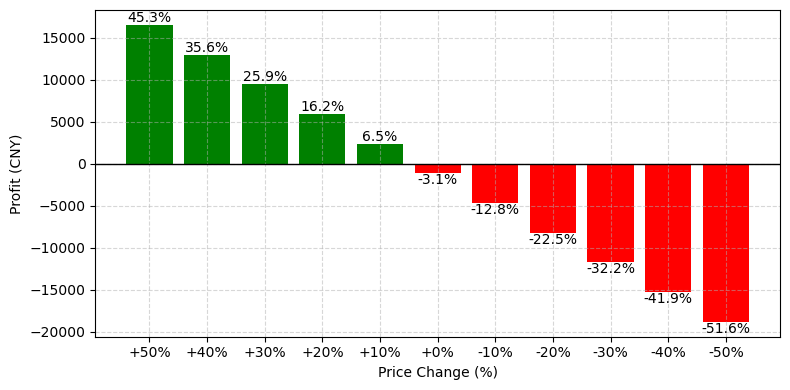

In [2]:
model = RiskModel()
df = model.price_change_simulation()

# Plot profit/loss bar chart
plt.figure(figsize=(8, 4))
bars = plt.bar(df['Price Change'], df['Profit (CNY)'], color=['g' if x > 0 else 'r' for x in df['Profit (CNY)']])

# Add profit rate labels
for bar, rate, profit in zip(bars, df['Profit Rate'], df['Profit (CNY)']):
    height = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2
    if profit >= 0:
        plt.text(x, height, rate, ha='center', va='bottom')
    else:
        plt.text(x, height, rate, ha='center', va='top')

plt.axhline(0, color='black', linewidth=1)
plt.xlabel('Price Change (%)')
plt.ylabel('Profit (CNY)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

--- Profit Stats ---
Mean profit (CNY): 29170
Median profit (CNY): 5460
Probability of loss: 44.1%
Worst case (CNY): -35279
Best case (CNY): 1130929

--- Max Drawdown Stats ---
Mean max drawdown: 62.4%
Median max drawdown: 62.1%
Worst max drawdown: 97.7%


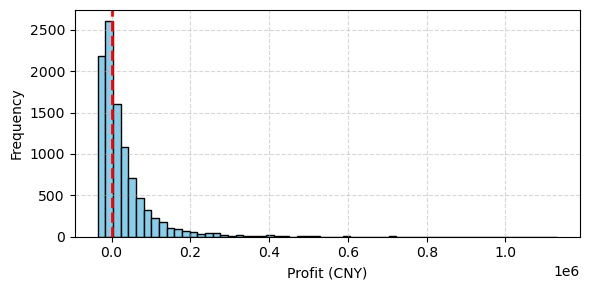

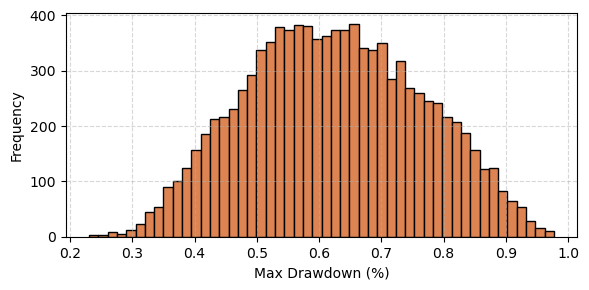

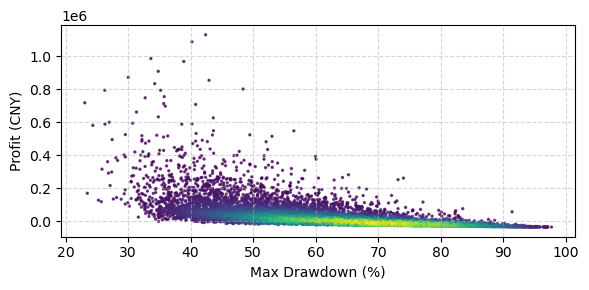

In [3]:
profits, mdds = model.monte_carlo()

# Summary statistics
print('--- Profit Stats ---')
print('Mean profit (CNY):', int(np.mean(profits)))
print('Median profit (CNY):', int(np.median(profits)))
print('Probability of loss: {:.1f}%'.format(np.mean(profits < 0) * 100))
print('Worst case (CNY):', int(np.min(profits)))
print('Best case (CNY):', int(np.max(profits)))

print('\n--- Max Drawdown Stats ---')
print('Mean max drawdown: {:.1f}%'.format(np.mean(mdds) * 100))
print('Median max drawdown: {:.1f}%'.format(np.median(mdds) * 100))
print('Worst max drawdown: {:.1f}%'.format(np.max(mdds) * 100))

# Plot Monte Carlo profit distribution
plt.figure(figsize=(6, 3))
plt.hist(profits, bins=60, color='skyblue', edgecolor='black')
plt.axvline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Profit (CNY)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot Monte Carlo max drawdown distribution
plt.figure(figsize=(6, 3))
plt.hist(mdds, bins=50, color='#DD8452', edgecolor='black')
plt.xlabel('Max Drawdown (%)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Risk–Return satter plot (profit vs. max drawdown)
plt.figure(figsize=(6, 3))
xy = np.vstack([mdds * 100, profits])
kde = gaussian_kde(xy)(xy)
plt.scatter(mdds*100, profits, c=kde, cmap='viridis', s=2, alpha=0.7,edgecolor=None)
plt.xlabel('Max Drawdown (%)')
plt.ylabel('Profit (CNY)')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

--- Profit Stats ---
Take-profit trigger rate: 80.5%
Stop-loss trigger rate: 19.5%
Hold rate: 0.0%
Mean profit (CNY): 6357
Median profit (CNY): 9465
Probability of loss: 19.5%
Worst case (CNY): -6459
Best case (CNY): 9465

--- Max Drawdown Stats ---
Mean max drawdown: 62.3%
Median max drawdown: 62.1%
Worst max drawdown: 96.7%


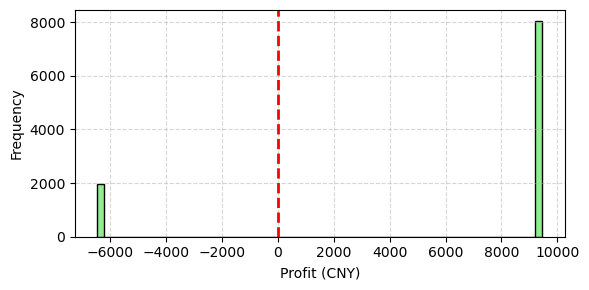

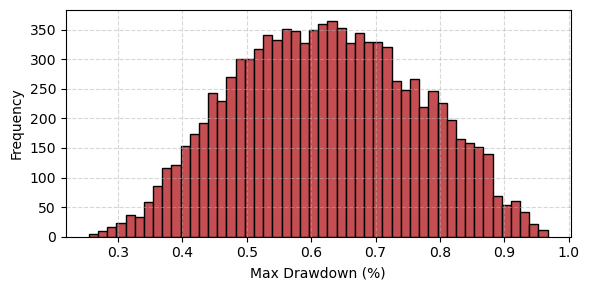

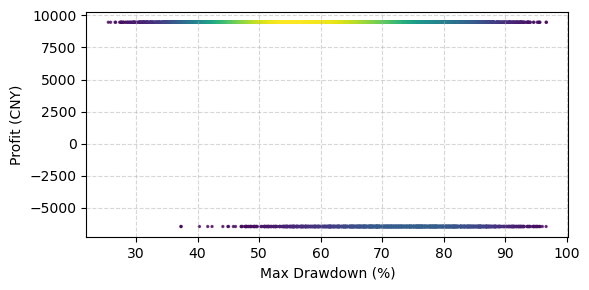

In [4]:
profits_1, triggers, mdds_1 = model.monte_carlo_strategy()

# Strategy statistics
print('--- Profit Stats ---')
print('Take-profit trigger rate: {:.1f}%'.format(np.mean(triggers == 'take-profit') * 100))
print('Stop-loss trigger rate: {:.1f}%'.format(np.mean(triggers == 'stop-loss') * 100))
print('Hold rate: {:.1f}%'.format(np.mean(triggers == 'hold') * 100))
print('Mean profit (CNY):', int(np.mean(profits_1)))
print('Median profit (CNY):', int(np.median(profits_1)))
print('Probability of loss: {:.1f}%'.format(np.mean(profits_1 < 0) * 100))
print('Worst case (CNY):', int(np.min(profits_1)))
print('Best case (CNY):', int(np.max(profits_1)))

print('\n--- Max Drawdown Stats ---')
print('Mean max drawdown: {:.1f}%'.format(np.mean(mdds_1) * 100))
print('Median max drawdown: {:.1f}%'.format(np.median(mdds_1) * 100))
print('Worst max drawdown: {:.1f}%'.format(np.max(mdds_1) * 100))

# Plot Monte Carlo (with strategy) profit distribution
plt.figure(figsize=(6, 3))
plt.hist(profits_1, bins=60, color='lightgreen', edgecolor='black')
plt.axvline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Profit (CNY)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Plot Monte Carlo (with strategy) max drawdown distribution
plt.figure(figsize=(6, 3))
plt.hist(mdds_1, bins=50, color='#C44E52', edgecolor='black')
plt.xlabel('Max Drawdown (%)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Risk–Return satter plot (profit vs. max drawdown)
plt.figure(figsize=(6, 3))
xy = np.vstack([mdds_1 * 100, profits_1])
kde = gaussian_kde(xy)(xy)
plt.scatter(mdds_1*100, profits_1, c=kde, cmap='viridis', s=2, alpha=0.7,edgecolor=None)
plt.xlabel('Max Drawdown (%)')
plt.ylabel('Profit (CNY)')
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()